1. # Practical 2 report: from relationships to predictive models

**Student:** Yelyzaveta Fisun  
**Date:** 26.09.2026  
**Practical:** 2 - Regression and evaluation


In [24]:
import pandas as pd
from sklearn.datasets import load_diabetes
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy import stats

In [29]:
RANDOM_STATE = 28092026

In [47]:
diabetes = load_diabetes(as_frame=True)

diabetes_df = diabetes.frame.copy()
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 2. Data-preparation readiness

Complete the checklist before describing modelling results. Tick an item only after checking the data or documenting a justified decision.

### Scientific purpose and provenance

- [x] Is the biological question and prediction task stated clearly?  
Yes, it is needed to predict severity of diabetes progression. 
- [x] Is the unit of observation clear?  
Yes, each row is a patient. 
- [x] Do I know where the data came from, how they were generated, and under which access conditions they may be used?  
Raw data can be accessed here https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt. Data comes from this paper 2004 paper by Efron, Hastie, Johnstone, and Tibshirani. 
- [x] Have I recorded the data version, processing history, and transformations already applied?  
Note: Each of these 10 feature variables have been mean centered and scaled by the standard deviation times the square root of n_samples (i.e. the sum of squares of each column totals 1). 

### Table shape and identifiers

- [x] Is the table tidy: one observation per row, one variable per column, and one value per cell?  
Yes. 
- [x] If needed, have I transposed the original assay into the format expected by the analysis tool?  
It is already in such format, samples - rows and features - columns.  
- [x] Are row names, column names, and identifiers clear, unique, and stable?  
We don't have any unique identifies from original dataset, but we can use index column for that. s1-s6 columns are not really clear, but description of these columns can be found here https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset. 
- [x] Can every feature and observation be traced to its source?  
It would be better to have id column but i will assume that preprossed (standartixed) data folow the order of original dataset. 
- [x] Are the feature matrix and metadata aligned by an explicit identifier rather than row order?  
In this case, features + target + metadat are in the same dataframe. 

### Types, values, and measurement meaning

- [x] Are numerical, categorical, ordinal, text, date, and identifier columns correctly classified?  
All columns are numerical.
- [x] Are units, scales, encodings, reference categories, and detection limits understood?  
All features are standardized.  
- [x] Have impossible values, inconsistent labels, unexpected categories, constant features, and extreme values been checked?  
Target variable follows right-skewed distribution.
- [x] Are normalization, scaling, log transformation, and batch-correction steps documented?  
Yas, and i checked if sum of each columns equals 1 and it works.

### Missing values

- [x] Have missing values been detected using all representations, not only `NaN`?  
No
- [x] Have missing values been measured by row, column, and relevant group?  
Yes
- [x] Do I know whether missingness is structural, technical, or plausibly related to biology or the target?
- [x] Have retention, removal, or imputation been justified?
- [x] If imputing, will the imputer be fitted on training data only?

In [48]:
missing_by_column = diabetes_df.isna().sum().sort_values(ascending=False)
missing_by_row = diabetes_df.isna().sum(axis=1)

display(missing_by_column.to_frame("missing_count"))
display((missing_by_column / len(diabetes_df)).to_frame("missing_fraction"))
print("Rows with at least one missing value:", int((missing_by_row > 0).sum()))
print("Rows with more than one missing value:", int((missing_by_row > 1).sum()))

,missing_count
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


,missing_fraction
age,0.0
sex,0.0
bmi,0.0
bp,0.0
s1,0.0
s2,0.0
s3,0.0
s4,0.0
s5,0.0
s6,0.0


Rows with at least one missing value: 0
Rows with more than one missing value: 0


### Replicates, dependence, and grouping

- [x] Have exact and near-duplicate observations been checked?
- [x] Are observations biological replicates, technical replicates, repeated measurements, pseudo-replicates, or independent samples?
- [x] Is the independent biological unit identified by a grouping variable?
- [x] Will related observations remain in the same train/validation/test split?
- [x] Is the provenance of synthetic or augmented observations recorded?

In [49]:
# Check exact duplicates and visible grouping variables.
print("Exact duplicate rows", int(diabetes_df.duplicated().sum()))

for column in ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6", "target"]:
    print(f"\nCounts for {column}:")
    display(diabetes_df[column].value_counts(dropna=False).to_frame("count"))


Exact duplicate rows 0

Counts for age:


,count
age,
0.016281,19
0.041708,17
0.009016,16
-0.027310,15
-0.001882,14
0.045341,14
-0.052738,14
0.012648,14
0.005383,13



Counts for sex:


,count
sex,
-0.044642,235
0.050680,207



Counts for bmi:


...

,count
s5,
-0.018114,11
-0.030748,10
-0.041176,8
-0.025953,7
-0.033246,7
...,...
0.031812,1
0.061684,1
0.030564,1



Counts for s6:


,count
s6,
0.003064,22
0.019633,20
0.007207,20
-0.001078,19
-0.017646,16
-0.013504,16
-0.038357,15
-0.009362,14
-0.054925,14



Counts for target:


,count
target,
200.0,6
72.0,6
90.0,5
71.0,5
178.0,5
...,...
146.0,1
212.0,1
120.0,1


### Target, leakage, confounding, and reproducibility

- [x] Is the target defined before modelling?  
Yes
- [x] Have identifiers, post-outcome variables, duplicated target information, and other leakage sources been excluded?  
Haven't found all of these.
- [x] Have batch, site, subject, treatment, sex, age, time, and other possible confounders been considered?  
- [x] Does the planned split represent the biological generalization question?
- [x] Are random seeds, software versions, file names, shapes, and preprocessing decisions recorded?

**Preparation summary:**

- Biological unit: patient 
- Number of observations and features: 442x11 
- Target and feature definition: target is score of diabetes progression amd features are different physiological characteristics
- Missing-value decision: [answer]
- Replicate/grouping decision: [answer]
- Main confounder or leakage source: No  
- Train/test split and justification: Yes
- Remaining concerns: [answer]

## 3 Your  task: Diabetes regression

### 3.1 Data presentation

Identify:

- one observation;
- the target variable;
- predictor variables;
- dimensionality of the dataset;
- whether the predictors and target have physical units or transformed scales.

In [2]:
diabetes = load_diabetes(as_frame=True)

diabetes_df = diabetes.frame.copy()
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### 3.2 Descriptive analysis

- Summarize the target.
- Visualize its distribution.
- Visualize at least three predictor-target relationships.
- State the biological or predictive question addressed by each plot.

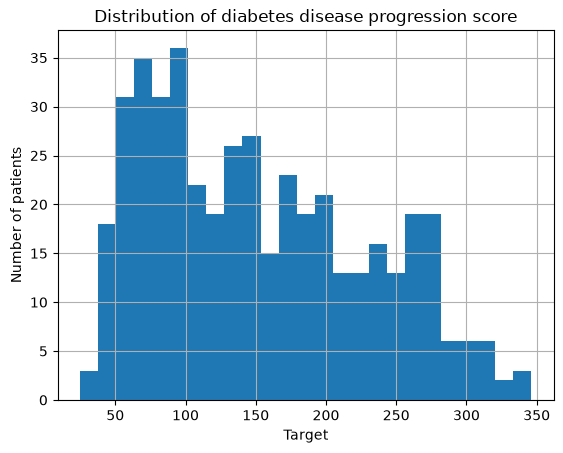

In [3]:
diabetes_df["target"].hist(bins=25)
plt.xlabel("Target")
plt.ylabel("Number of patients")
plt.title("Distribution of diabetes disease progression score")
plt.show()

We observe that distribution of target is highly right-skewed.

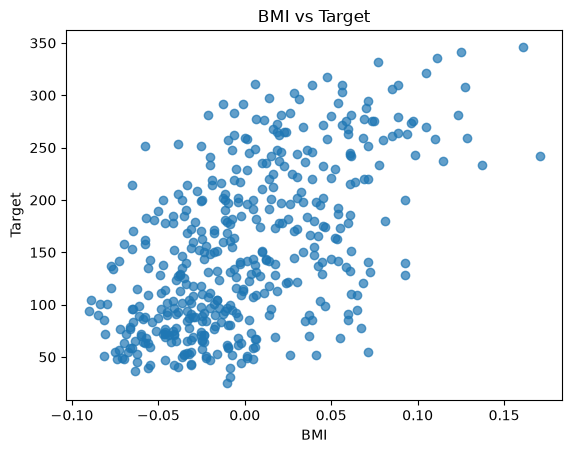

In [4]:
plot_df = diabetes_df.dropna(subset=["target", "bmi"])

plt.scatter(plot_df["bmi"], plot_df["target"], alpha=0.7)
plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("BMI vs Target")
plt.show()

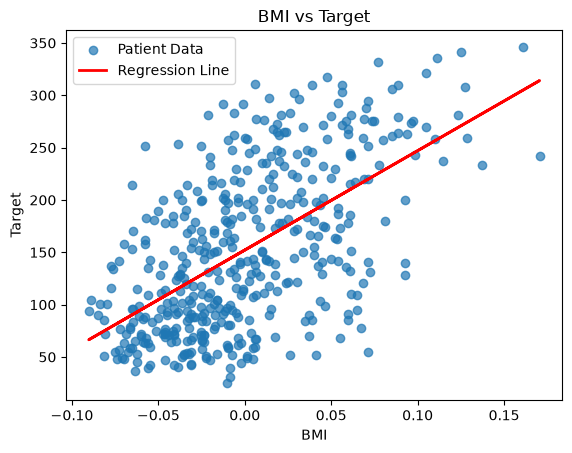

949.4352603840234 152.13348416289625


In [ ]:
plot_df = diabetes_df.dropna(subset=["target", "bmi"])


x = plot_df["bmi"]
y = plot_df["target"]

# 1. Calculate the line of best fit (1st degree polynomial)
slope, intercept = np.polyfit(x, y, 1)

# 2. Generate the y-values for the regression line
trendline = slope * x + intercept

# Original scatter plot
plt.scatter(x, y, alpha=0.7, label="Patient Data")

# 3. Plot the regression line
plt.plot(x, trendline, color='red', linewidth=2, label="Regression Line")

plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("BMI vs Target")
plt.legend()
plt.show()
print(slope, intercept)

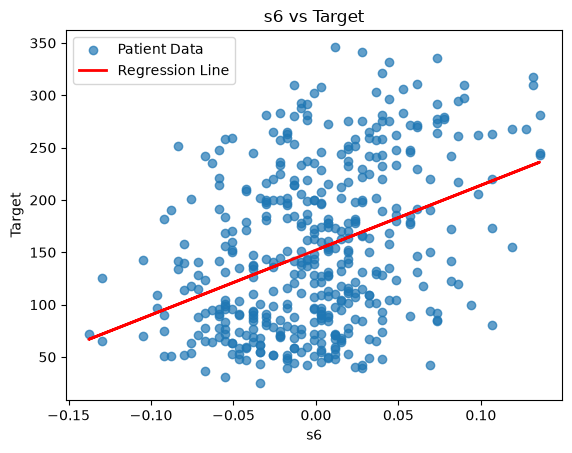

619.2228206843721 152.133484162896


In [ ]:
plot_df = diabetes_df.dropna(subset=["target", "s6"])

x = plot_df["s6"]
y = plot_df["target"]

# 1. Calculate the line of best fit (1st degree polynomial)
slope, intercept = np.polyfit(x, y, 1)

# 2. Generate the y-values for the regression line
trendline = slope * x + intercept

# Original scatter plot
plt.scatter(x, y, alpha=0.7, label="Patient Data")

# 3. Plot the regression line
plt.plot(x, trendline, color='red', linewidth=2, label="Regression Line")

plt.xlabel("s6")
plt.ylabel("Target")
plt.title("s6 vs Target")
plt.legend()
plt.show()
print(slope, intercept)

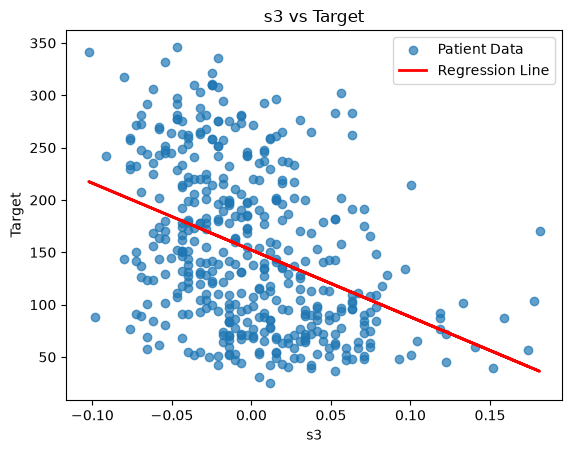

-639.1452793225353 152.13348416289585


In [ ]:
plot_df = diabetes_df.dropna(subset=["target", "s3"])

x = plot_df["s3"]
y = plot_df["target"]

# 1. Calculate the line of best fit (1st degree polynomial)
slope, intercept = np.polyfit(x, y, 1)

# 2. Generate the y-values for the regression line
trendline = slope * x + intercept

# Original scatter plot
plt.scatter(x, y, alpha=0.7, label="Patient Data")

# 3. Plot the regression line
plt.plot(x, trendline, color='red', linewidth=2, label="Regression Line")

plt.xlabel("s3")
plt.ylabel("Target")
plt.title("s3 vs Target")
plt.legend()
plt.show()
print(slope, intercept)

From descriptive analysis we can observe that bmi and s6 have positive relationship, but with s3 we observe negative relationship.  Also all three plots have high variance.  
We can start with the model target ~ bmi

### 3.3 Correlation

- Calculate correlation using ar least 2 different methods.
- Identify the predictor most strongly correlated with the target.
- Compare results.
- Explain why correlation is not sufficient for feature selection or causal interpretation.

In [15]:
numeric_cols = diabetes_df.columns
corr_df = diabetes_df[numeric_cols].dropna()
corr_df.corr(method="pearson")

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


In [16]:
corr_df.corr(method="spearman")

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.000000,0.177463,0.200554,0.350859,0.262524,0.221711,-0.106973,0.221017,0.265176,0.296235,0.197822
sex,0.177463,1.000000,0.098079,0.261508,0.027790,0.134695,-0.394584,0.337524,0.174625,0.203277,0.037401
bmi,0.200554,0.098079,1.000000,0.397985,0.287829,0.295494,-0.371172,0.459068,0.491609,0.384664,0.561382
bp,0.350859,0.261508,0.397985,1.000000,0.275224,0.205638,-0.191033,0.280799,0.396071,0.381219,0.416241
s1,0.262524,0.027790,0.287829,0.275224,1.000000,0.878793,0.015308,0.520674,0.512864,0.332173,0.232429
s2,0.221711,0.134695,0.295494,0.205638,0.878793,1.000000,-0.197435,0.652283,0.349947,0.286483,0.195834
s3,-0.106973,-0.394584,-0.371172,-0.191033,0.015308,-0.197435,1.000000,-0.789694,-0.450420,-0.290863,-0.410022
s4,0.221017,0.337524,0.459068,0.280799,0.520674,0.652283,-0.789694,1.000000,0.640390,0.413700,0.448931
s5,0.265176,0.174625,0.491609,0.396071,0.512864,0.349947,-0.450420,0.640390,1.000000,0.453023,0.589416
s6,0.296235,0.203277,0.384664,0.381219,0.332173,0.286483,-0.290863,0.413700,0.453023,1.000000,0.350792


BMI and s5 shows high positive correlation with target. These results are concistent between two methods. Correlation doesn't show causality. Also it is important to keep in mind that we can't just put all high correlated features in the model, because we risk having features correlated with each other (multicolinearity). 

### 4.4 Simple regression

Choose one predictor and fit a simple linear regression. Report and interpret:

- intercept;
- slope;
- the scale of the predictor;
- whether the slope is a causal effect.

In [18]:
simple_df = diabetes_df[["bmi", "target"]].dropna()

X_simple = simple_df[["bmi"]]
y_simple = simple_df["target"]

simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)

print("Intercept:", simple_model.intercept_)
print("Slope:", simple_model.coef_[0])

Intercept: 152.13348416289617
Slope: 949.4352603840388


If x=0 in our case it's average value of bmi, because we have mean centered data, target is 152.13.  
When bmi increases with one unit, target increases with 949.

### 4.5 Residual diagnostics

Produce:

- observed versus predicted plot;
- residuals versus fitted plot;
- residual histogram;
- Q-Q plot.

Discuss linearity, homoscedasticity, residual normality, unusual observations, and any limitations of the diagnostics.

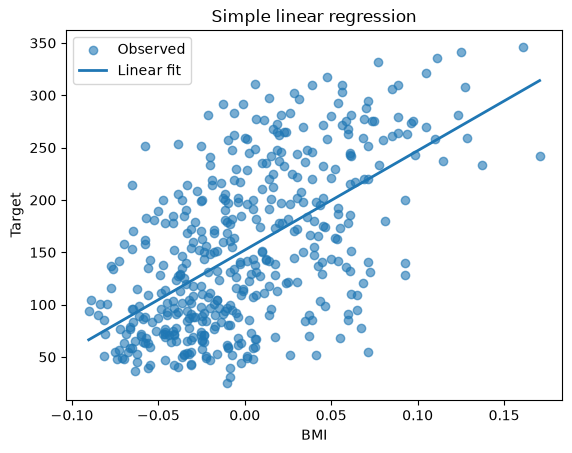

In [20]:
y_hat_simple = simple_model.predict(X_simple)

order = np.argsort(X_simple["bmi"].to_numpy())

plt.scatter(X_simple["bmi"], y_simple, alpha=0.6, label="Observed")

plt.plot(X_simple["bmi"].to_numpy()[order], y_hat_simple[order], linewidth=2, label="Linear fit")

plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("Simple linear regression")
plt.legend()
plt.show()

In [21]:
residuals = y_simple.to_numpy() - y_hat_simple

residual_df = pd.DataFrame({
    "observed": y_simple.to_numpy(),
    "predicted": y_hat_simple,
    "residual": residuals})

residual_df.head()

,observed,predicted,residual
0,151.0,210.710038,-59.710038
1,75.0,103.262195,-28.262195
2,141.0,194.337033,-53.337033
3,206.0,141.124769,64.875231
4,135.0,117.588574,17.411426


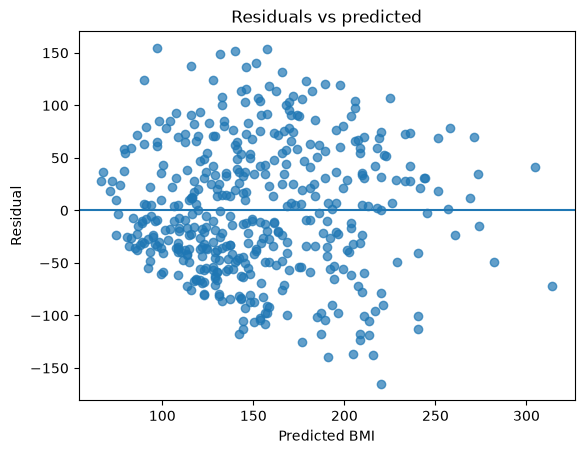

In [22]:
plt.scatter(
    residual_df["predicted"],
    residual_df["residual"],
    alpha=0.7)

plt.axhline(0)
plt.xlabel("Predicted BMI")
plt.ylabel("Residual")
plt.title("Residuals vs predicted")
plt.show()

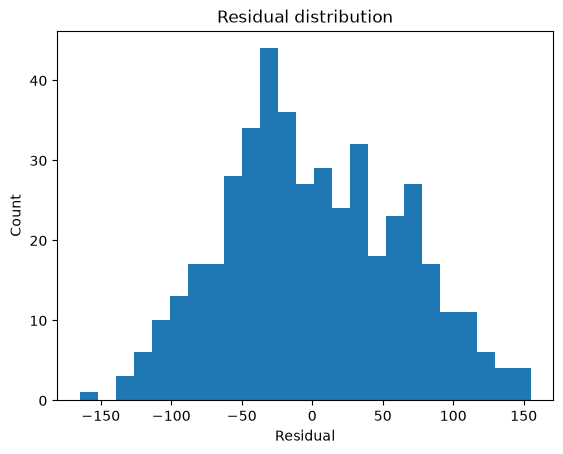

In [23]:
plt.hist(residuals, bins=25)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.show()

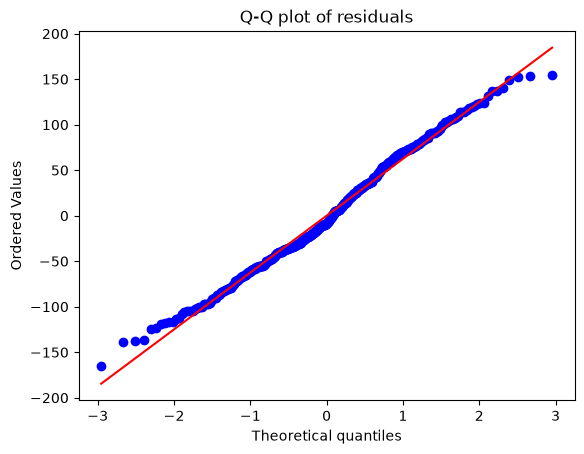

In [25]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot of residuals")
plt.show()

Residuals histogram and Q-Q plot follow more or less normal distribution and homoskedastic.

### 4.6 Multiple regression and multicollinearity

Fit a model using all available predictors. Inspect:

- coefficients;
- predictor correlations;
- possible multicollinearity;
- whether standardized predictors change coefficient interpretation.

In [26]:
diabetes_df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='str')

In [38]:
multiple_cols = ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6", "target"]

multiple_df = diabetes_df[multiple_cols].dropna()

X_multiple = multiple_df[["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"]]
y_multiple = multiple_df["target"]

multiple_model = LinearRegression()
multiple_model.fit(X_multiple, y_multiple)

coef_table = pd.DataFrame({"feature": X_multiple.columns, "coefficient": multiple_model.coef_})

coef_table

,feature,coefficient
0,age,-10.009866
1,sex,-239.815644
2,bmi,519.845920
3,bp,324.384646
4,s1,-792.175639
5,s2,476.739021
6,s3,101.043268
7,s4,177.063238
8,s5,751.273700
9,s6,67.626692


In [39]:
X_multiple.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


s1 and s2 are highly correlated, also s4 and s5 have moderate correlation. Strong predictor correlation can destabilize coefficient estimates.

if values are standardized coefficient of linear regression should be interpreted in such way, when x_i is changed by one standard deviation, y is changed by b_i coefficient. 

### 4.7 Train/test evaluation

Create a justified train/test split and report MAE, MSE, RMSE, and $R^2$. Compare simple and multiple regression on test data.

Explain whether the split answers the intended biological or clinical generalization question.

In [40]:
evaluation_df = diabetes_df[
    multiple_cols].dropna()

X = evaluation_df.drop(columns="target")
y = evaluation_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE)

In [42]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)}

In [43]:
results = []
# Model 1: BMI only
m1 = LinearRegression()
m1.fit(X_train[["bmi"]], y_train)

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("test", X_test, y_test)]:
    pred = m1.predict(X_split[["bmi"]])
    metrics = regression_metrics(y_split, pred)
    results.append({
        "model": "BMI only",
        "split": split_name,
        **metrics })
metrics

{'MAE': 55.43129268182327,
 'MSE': 4273.046300887474,
 'RMSE': np.float64(65.36854213524633),
 'R2': 0.28611539378329565}

In [44]:
# Model 2: all features
m2_features = [
    "age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"]

m2 = LinearRegression()
m2.fit(X_train[m2_features], y_train)

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("test", X_test, y_test)]:
    pred = m2.predict(X_split[m2_features])
    metrics = regression_metrics(y_split, pred)
    results.append({
        "model": "All features",
        "split": split_name,
        **metrics })
metrics

{'MAE': 46.685877589853824,
 'MSE': 3215.411386642538,
 'RMSE': np.float64(56.70459757940743),
 'R2': 0.46281118201287097}

In [45]:
results_df = pd.DataFrame(results)
results_df

,model,split,MAE,MSE,RMSE,R2
0,BMI only,train,50.579544,3799.642305,61.641239,0.357218
1,BMI only,test,55.431293,4273.046301,65.368542,0.286115
2,All features,train,42.481225,2790.149947,52.821870,0.527993
3,All features,test,46.685878,3215.411387,56.704598,0.462811


In [46]:
results_df[results_df["split"] == "test"].sort_values("RMSE")

,model,split,MAE,MSE,RMSE,R2
3,All features,test,46.685878,3215.411387,56.704598,0.462811
1,BMI only,test,55.431293,4273.046301,65.368542,0.286115


In general model with all features shows better results for RMS and R2. But i would say that RMSE is still high in model 2. In addition, i would be very critical to analyze raw R2 score, because it is quite sensitive when we increase number of predictors, it can increase synthetically, better to look at R2_adjusted.

### 4.8 Independent-task conclusion

Answer:

1. Which model generalized better?
2. Did adding more variables help?
3. Are any regression assumptions questionable?
4. Are coefficient interpretations straightforward?
5. What is one important limitation of the dataset or model?

Remember that the predictors from `load_diabetes()` are already standardized.

1. One with all features.
2. Probably yes, but we should keep in mind that we have couple of predictor that are highly correlated with each other.
3. Homoskedasticity of residuals, Multicolinearity
4. No, when predictors are highly correlated, we cannot interpret a coefficient as the isolated effect of that single variable.
5. It seems to me that model can be too simple for this data, probably here it is not strict linear relationship. 